<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/PAI_from_Las_TN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install laspy numpy pandas matplotlib rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 59.1 MB/s eta 0:00:00


Load data

In [3]:
import laspy
import numpy as np

las_file = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW.las"

# Open file
las = laspy.read(las_file)

# Access point data
z = las.z  # elevation
intensity = las.intensity


Across the whole scene what is the PAI

Plant Area Index (PAI) is often estimated using gap fraction theory (Beer-Lambert law).

PAI=−Ω1​ln(Pgap​)

In [ ]:
# Classify returns: ground vs vegetation
# If the LAS file has classification codes:
# 2 = ground, 1 = unclassified/veg, etc.
if hasattr(las, "classification"):
    ground_mask = (las.classification == 2)
else:
    raise ValueError("LAS file does not contain classification info.")

n_total = len(las.points)
n_ground = np.sum(ground_mask)

P_gap = n_ground / n_total
PAI = -np.log(P_gap)  # assuming Ω = 1

print(f"Gap Fraction (P_gap): {P_gap:.3f}")
print(f"Estimated Plant Area Index (PAI): {PAI:.3f}")


Gap Fraction (P_gap): 0.368
Estimated Plant Area Index (PAI): 1.000


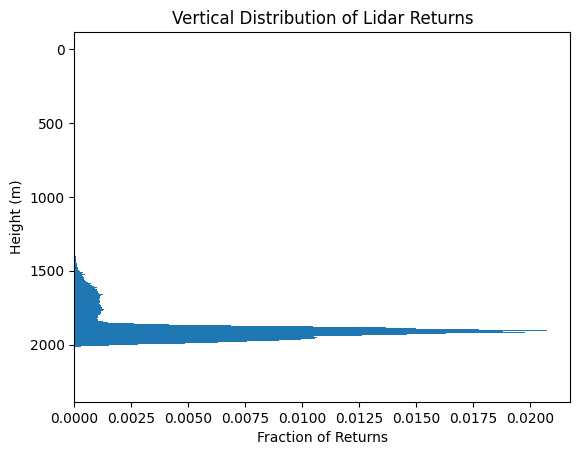

In [ ]:
# Bin by height
bins = np.arange(0, max(z), 2)  # 2 m bins
counts, _ = np.histogram(z, bins=bins)

# Normalize to get density profile
density = counts / np.sum(counts)

import matplotlib.pyplot as plt

plt.barh(bins[:-1], density, height=2, align='edge')
plt.xlabel("Fraction of Returns")
plt.ylabel("Height (m)")
plt.title("Vertical Distribution of Lidar Returns")
plt.gca().invert_yaxis()
plt.show()


Grid Approach for PAI

PAIcell​=−ln(Pgap,cell​)

In [ ]:
import numpy as np
import laspy

def estimate_las_resolution(las_file):
    las = laspy.read(las_file)

    # Extract coordinates
    x, y = las.x, las.y

    # Bounding box
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    area = (x_max - x_min) * (y_max - y_min)  # m²

    n_points = len(x)
    density = n_points / area   # points per m²
    spacing = np.sqrt(1 / density)  # nominal point spacing (m)

    return {
        "n_points": n_points,
        "area_m2": area,
        "point_density_per_m2": density,
        "nominal_spacing_m": spacing
    }

# Example usage
las_file = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW.las"
res_stats = estimate_las_resolution(las_file)
print(res_stats)


{'n_points': 20929456, 'area_m2': np.float64(28000000.0), 'point_density_per_m2': np.float64(0.7474805714285714), 'nominal_spacing_m': np.float64(1.156644895440166)}


nominal spacing ≈ 1.16 m (point density ≈ 0.75 pts/m²) means this is relatively sparse compared with airborne LiDAR, Reccomend  a coarser grid for stable per-cell PAI (e.g., ~10 m cells is a reasonable starting point).

In [ ]:
# import numpy as np

# def recommend_cell_size(nominal_spacing_m):
#     """
#     Heuristic to recommend a grid cell size (meters) for per-cell metrics
#     based on nominal point spacing (m).
#     Returns an integer meter value.
#     Rationale:
#       - Keep cell >> spacing so each cell contains multiple points on average.
#       - For spacing ~1 m, 8-12 m cells are typically stable at ~0.75 pts/m2.
#     """
#     s = float(nominal_spacing_m)
#     # basic rules (tunable)
#     if s < 0.2:
#         cell = 5
#     elif s < 0.5:
#         cell = 5
#     elif s < 2.0:
#         cell = 10
#     elif s < 5.0:
#         cell = 20
#     else:
#         cell = 25
#     return int(cell)

# # Example using your value:
# nominal_spacing =1.156644895440166
# print("recommended cell size (m):", recommend_cell_size(nominal_spacing))
# # -> expected: 10 m


recommended cell size (m): 5


In [ ]:
# import laspy
# import numpy as np
# import pandas as pd
# import rasterio
# from rasterio.transform import from_origin
# import math
# import os

# def compute_pai_grid(
#     las_path,
#     cell_size=None,
#     min_points_per_cell=5,
#     clumping_index=1.0,
#     ground_class_code=2,
#     ground_percentile_fallback=1.0,
#     output_tif=None
# ):
#     """
#     Compute spatially-explicit PAI (per-cell) from a LAS file.
#     - If cell_size is None, it will be recommended automatically from nominal spacing.
#     - Uses classification==ground_class_code as ground if present.
#       If classification missing or no ground points in cell, uses a fallback:
#       considers points <= percentile (ground_percentile_fallback) as ground approximation.
#     - Returns: (grid_df, heatmap_array, transform, raster_path)
#       where grid_df has columns: x_bin, y_bin, x_min, y_min, n_points, n_ground, P_gap, PAI.
#     - Writes GeoTIFF if output_tif provided (or auto-named next to las file).
#     """
#     las = laspy.read(las_path)
#     x = las.x
#     y = las.y
#     z = las.z
#     n_points = len(x)

#     # bounding box
#     x_min, x_max = float(x.min()), float(x.max())
#     y_min, y_max = float(y.min()), float(y.max())
#     width_m = x_max - x_min
#     height_m = y_max - y_min

#     # nominal spacing (approx)
#     area = width_m * height_m
#     density = n_points / area if area > 0 else np.nan
#     nominal_spacing = np.sqrt(1.0 / density) if density > 0 else np.nan

#     # choose cell size
#     if cell_size is None:
#         cell_size = recommend_cell_size(nominal_spacing)

#     # grid bins
#     nx = int(math.ceil(width_m / cell_size))
#     ny = int(math.ceil(height_m / cell_size))

#     # compute bin indices for every point
#     x_idx = ((x - x_min) // cell_size).astype(int)
#     y_idx = ((y - y_min) // cell_size).astype(int)

#     # make sure indices fall in [0, nx-1], [0, ny-1]
#     x_idx = np.clip(x_idx, 0, nx-1)
#     y_idx = np.clip(y_idx, 0, ny-1)

#     # classification handling
#     has_class = hasattr(las, "classification")
#     if has_class:
#         try:
#             cls = las.classification
#             has_class = True
#         except Exception:
#             has_class = False

#     # prepare storage arrays
#     n_total_cell = np.zeros((ny, nx), dtype=np.int32)
#     n_ground_cell = np.zeros((ny, nx), dtype=np.int32)

#     # iterate points and accumulate counts
#     # vectorized approach: combine x_idx,y_idx -> linear index
#     lin_idx = y_idx * nx + x_idx
#     # total counts per linear index
#     unique_idx, counts = np.unique(lin_idx, return_counts=True)
#     n_total_cell_flat = np.zeros(nx * ny, dtype=np.int32)
#     n_total_cell_flat[unique_idx] = counts

#     # ground counts
#     if has_class:
#         ground_mask = (cls == ground_class_code)
#         ground_lin = lin_idx[ground_mask]
#         if ground_lin.size > 0:
#             unique_g, counts_g = np.unique(ground_lin, return_counts=True)
#             n_ground_cell_flat = np.zeros(nx * ny, dtype=np.int32)
#             n_ground_cell_flat[unique_g] = counts_g
#         else:
#             n_ground_cell_flat = np.zeros(nx * ny, dtype=np.int32)
#     else:
#         # fallback: for each cell, approximate ground as lowest percentile of z within cell
#         n_ground_cell_flat = np.zeros(nx * ny, dtype=np.int32)
#         # we will compute per-cell z-percentile
#         # map each point to its cell linear index and process groups
#         # Using pandas groupby is convenient here:
#         #import pandas as pd
#         df_pts = pd.DataFrame({"lin": lin_idx, "z": z})
#         grouped = df_pts.groupby("lin")["z"]
#         for lin, series in grouped:
#             if len(series) < 1:
#                 continue
#             pct = np.percentile(series.values, ground_percentile_fallback)
#             # define ground as points within 0.5 m above that percentile (tunable)
#             ground_count = np.sum(series.values <= (pct + 0.5))
#             n_ground_cell_flat[int(lin)] = int(ground_count)

#     # reshape to 2D arrays (ny rows (y), nx cols (x))
#     n_total_cell = n_total_cell_flat.reshape((ny, nx))
#     n_ground_cell = n_ground_cell_flat.reshape((ny, nx))

#     # compute P_gap and PAI per cell
#     P_gap = np.full((ny, nx), np.nan, dtype=np.float32)
#     PAI = np.full((ny, nx), np.nan, dtype=np.float32)

#     valid_mask = n_total_cell >= min_points_per_cell
#     with np.errstate(divide='ignore', invalid='ignore'):
#         P_gap_temp = np.where(valid_mask, n_ground_cell.astype(float) / n_total_cell.astype(float), np.nan)
#         # enforce P_gap bounds (can't be 0 for log) — if 0 -> set to tiny number to denote very dense veg (or NaN)
#         # but better to set to NaN to indicate unreliable
#         tiny = 1e-6
#         P_gap_temp = np.where(P_gap_temp <= 0.0, tiny, P_gap_temp)
#         PAI_temp = - (1.0 / clumping_index) * np.log(P_gap_temp)
#         # mark cells with zero ground as large PAI but we already replaced 0->tiny giving a large PAI
#         P_gap = P_gap_temp
#         PAI = np.where(valid_mask, PAI_temp, np.nan)

#     # build dataframe of cells
#     records = []
#     for iy in range(ny):
#         for ix in range(nx):
#             x0 = x_min + ix * cell_size
#             y0 = y_min + iy * cell_size
#             records.append({
#                 "x_bin": ix,
#                 "y_bin": iy,
#                 "x_min": x0,
#                 "y_min": y0,
#                 "n_points": int(n_total_cell[iy, ix]),
#                 "n_ground": int(n_ground_cell[iy, ix]),
#                 "P_gap": float(P_gap[iy, ix]) if not np.isnan(P_gap[iy, ix]) else np.nan,
#                 "PAI": float(PAI[iy, ix]) if not np.isnan(PAI[iy, ix]) else np.nan
#             })
#     grid_df = pd.DataFrame.from_records(records)

#     # prepare GeoTIFF transform (top-left origin)
#     # rasterio expects origin top-left: we'll arrange rows from top (y_max) to bottom (y_min)
#     transform = from_origin(x_min, y_max, cell_size, cell_size)  # (west, north, xsize, ysize)

#     # If user wants GeoTIFF, write it (PAI band)
#     if output_tif is None:
#         base = os.path.splitext(os.path.basename(las_path))[0]
#         output_tif = os.path.join(os.path.dirname(las_path), f"{base}_PAI_{cell_size}m.tif")

#     # flip PAI vertically because our ny rows go from y_min -> y_max, but rasterio expects top->bottom
#     pai_for_raster = np.flipud(PAI)  # now row 0 is y_max

#     # write with rasterio (single band float32, nodata = -9999)
#     os.makedirs(os.path.dirname(output_tif), exist_ok=True)
#     with rasterio.Env():
#         new_dataset = rasterio.open(
#             output_tif,
#             'w',
#             driver='GTiff',
#             height=pai_for_raster.shape[0],
#             width=pai_for_raster.shape[1],
#             count=1,
#             dtype=pai_for_raster.dtype,
#             crs=None,  # preserves no CRS; if LAS has a known CRS you can pass it here
#             transform=transform,
#             nodata=np.nan,
#             compress='lzw'
#         )
#         new_dataset.write(pai_for_raster, 1)
#         new_dataset.close()

#     return {
#         "grid_df": grid_df,
#         "pai_array": PAI,
#         "transform": transform,
#         "raster_path": output_tif,
#         "cell_size": cell_size,
#         "nominal_spacing": nominal_spacing,
#         "point_density_per_m2": density
#     }

# # Example usage
# las_file = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW.las"
# out = compute_pai_grid(las_file, cell_size=None, min_points_per_cell=5, output_tif=None)
# print("Wrote PAI raster to:", out["raster_path"])
# print("Cells:", out["grid_df"].shape[0], "Cell size (m):", out["cell_size"])


Wrote PAI raster to: /content/drive/MyDrive/GEDI_LAS_Comp/1982317NW_PAI_10m.tif
Cells: 280000 Cell size (m): 10


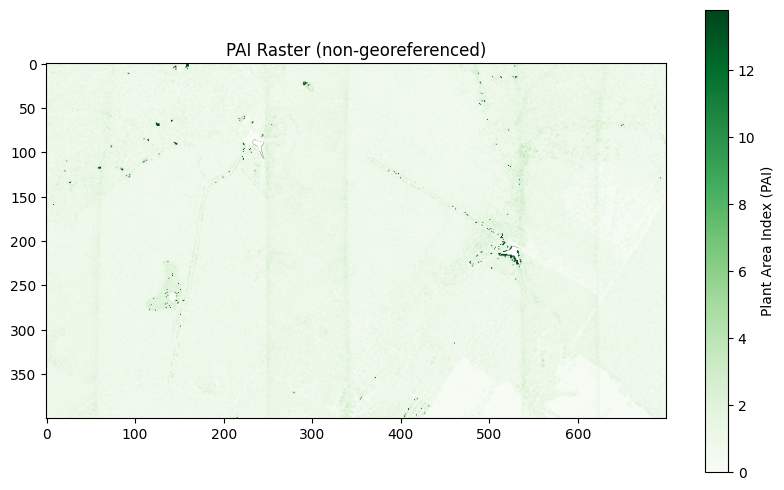

In [ ]:
# import rasterio
# import matplotlib.pyplot as plt
# import numpy as np

# raster_path = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW_PAI_10m.tif"

# with rasterio.open(raster_path) as src:
#     array = src.read(1, masked=True).astype(float)

# # Mask invalid values
# array = np.ma.masked_invalid(array)

# plt.figure(figsize=(10,6))
# plt.imshow(array, cmap="Greens", origin="upper")
# plt.colorbar(label="Plant Area Index (PAI)")
# plt.title("PAI Raster (non-georeferenced)")
# plt.show()


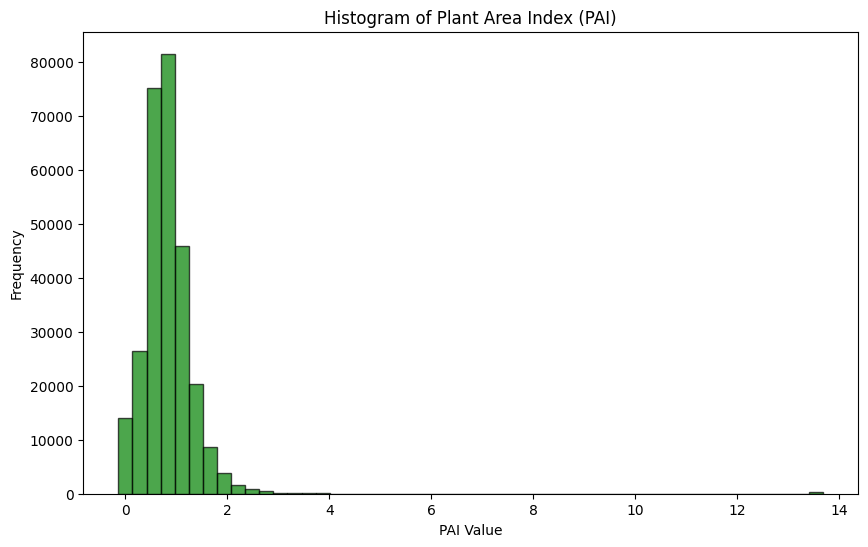

In [ ]:
# import rasterio
# import numpy as np
# import matplotlib.pyplot as plt

# raster_path = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW_PAI_10m.tif"

# # Open raster
# with rasterio.open(raster_path) as src:
#     array = src.read(1, masked=True).astype(float)  # Read first band

# # Mask invalid values
# array = np.ma.masked_invalid(array)

# # Flatten valid values for histogram
# valid_values = array.compressed()  # removes masked/NaN

# # Compute histogram
# hist, bins = np.histogram(valid_values, bins=50)  # 50 bins, adjust if needed

# # Plot histogram
# plt.figure(figsize=(10,6))
# plt.bar(bins[:-1], hist, width=(bins[1]-bins[0]), color='green', edgecolor='black', alpha=0.7)
# plt.xlabel("PAI Value")
# plt.ylabel("Frequency")
# plt.title("Histogram of Plant Area Index (PAI)")
# plt.show()


zzzzzzzzzzzzzzzzzzzzzzzzz

fix with crs appended

In [6]:
import laspy
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin
import math
import os

def recommend_cell_size(nominal_spacing, multiplier=10):
    """Suggest grid cell size ~10x nominal point spacing."""
    if np.isnan(nominal_spacing) or nominal_spacing <= 0:
        return 10.0
    return round(multiplier * nominal_spacing, 1)

def compute_pai_grid(
    las_path,
    cell_size=10, #None,
    min_points_per_cell=5,
    clumping_index=1.0,
    ground_class_code=2,
    ground_percentile_fallback=1.0,
    output_tif=None,
    default_epsg=32616   # ✅ Tennessee → UTM Zone 16N (WGS84)
):
    """
    Compute spatially-explicit PAI (per-cell) from a LAS file, with CRS preserved.
    """
    las = laspy.read(las_path)
    x, y, z = las.x, las.y, las.z
    n_points = len(x)

    # bounding box
    x_min, x_max = float(x.min()), float(x.max())
    y_min, y_max = float(y.min()), float(y.max())
    width_m, height_m = x_max - x_min, y_max - y_min

    # nominal spacing
    area = width_m * height_m
    density = n_points / area if area > 0 else np.nan
    nominal_spacing = np.sqrt(1.0 / density) if density > 0 else np.nan

    if cell_size is None:
        cell_size = recommend_cell_size(nominal_spacing)

    # grid dims
    nx, ny = int(math.ceil(width_m / cell_size)), int(math.ceil(height_m / cell_size))
    x_idx = ((x - x_min) // cell_size).astype(int)
    y_idx = ((y - y_min) // cell_size).astype(int)
    x_idx, y_idx = np.clip(x_idx, 0, nx - 1), np.clip(y_idx, 0, ny - 1)

    # classification
    try:
        cls = las.classification
        has_class = True
    except Exception:
        has_class = False

    # counts
    lin_idx = y_idx * nx + x_idx
    unique_idx, counts = np.unique(lin_idx, return_counts=True)
    n_total_cell_flat = np.zeros(nx * ny, dtype=np.int32)
    n_total_cell_flat[unique_idx] = counts

    if has_class:
        ground_mask = (cls == ground_class_code)
        ground_lin = lin_idx[ground_mask]
        unique_g, counts_g = np.unique(ground_lin, return_counts=True)
        n_ground_cell_flat = np.zeros(nx * ny, dtype=np.int32)
        n_ground_cell_flat[unique_g] = counts_g
    else:
        n_ground_cell_flat = np.zeros(nx * ny, dtype=np.int32)
        df_pts = pd.DataFrame({"lin": lin_idx, "z": z})
        for lin, series in df_pts.groupby("lin")["z"]:
            pct = np.percentile(series.values, ground_percentile_fallback)
            n_ground_cell_flat[int(lin)] = np.sum(series.values <= (pct + 0.5))

    n_total_cell = n_total_cell_flat.reshape((ny, nx))
    n_ground_cell = n_ground_cell_flat.reshape((ny, nx))

    valid_mask = n_total_cell >= min_points_per_cell
    tiny = 1e-6
    with np.errstate(divide="ignore", invalid="ignore"):
        P_gap_temp = np.where(valid_mask, n_ground_cell / n_total_cell, np.nan)
        P_gap_temp = np.where(P_gap_temp <= 0.0, tiny, P_gap_temp)
        PAI = np.where(valid_mask, -(1.0 / clumping_index) * np.log(P_gap_temp), np.nan)

    # flip for raster
    pai_for_raster = np.flipud(PAI.astype(np.float32))
    transform = from_origin(x_min, y_max, cell_size, cell_size)

    # ✅ Try to extract CRS from LAS
    crs = None
    if las.header.parse_crs() is not None:
        crs = las.header.parse_crs()
    else:
        crs = rasterio.crs.CRS.from_epsg(default_epsg)  # fallback

    if output_tif is None:
        base = os.path.splitext(os.path.basename(las_path))[0]
        output_tif = os.path.join(os.path.dirname(las_path), f"{base}_PAI_{cell_size}m.tif")

    os.makedirs(os.path.dirname(output_tif), exist_ok=True)
    with rasterio.open(
        output_tif,
        "w",
        driver="GTiff",
        height=pai_for_raster.shape[0],
        width=pai_for_raster.shape[1],
        count=1,
        dtype="float32",
        crs=crs,   # ✅ write CRS
        transform=transform,
        nodata=np.nan,
        compress="lzw",
    ) as dst:
        dst.write(pai_for_raster, 1)

    return {
        "raster_path": output_tif,
        "grid_df": pd.DataFrame({"lin": range(len(n_total_cell_flat)), "n_points": n_total_cell_flat}),
        "cell_size": cell_size,
        "crs": crs,
        "density": density,
        "nominal_spacing": nominal_spacing,
    }

# Example
las_file = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW.las"
out = compute_pai_grid(las_file, min_points_per_cell=5)
print("✅ Wrote PAI raster:", out["raster_path"])
print("CRS:", out["crs"])


✅ Wrote PAI raster: /content/drive/MyDrive/GEDI_LAS_Comp/1982317NW_PAI_10m.tif
CRS: COMPD_CS["NAD83(2011) / Tennessee (ftUS) / NAVD88 height - Geoid12B (ftUS)",PROJCS["NAD83(2011) / Tennessee (ftUS)",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["standard_parallel_1",36.41666666666666],PARAMETER["standard_parallel_2",35.25],PARAMETER["latitude_of_origin",34.33333333333334],PARAMETER["central_meridian",-86],PARAMETER["false_easting",1968500],PARAMETER["false_northing",0],UNIT["US survey foot",0.3048006096012192,AUTHORITY["EPSG","9003"]],AXIS["X",EAST],AXIS["Y",NORTH],AUTHORITY["EPSG","6576"]],VERT_CS["NAVD88 height - Geoid12B (ftUS)",VERT_DATUM["North American Vertical Datum 1988",2005,

✅ Reprojected raster saved at: /content/drive/MyDrive/GEDI_LAS_Comp/1982317NW_PAI_10m_wgs84.tif
Raster PAI range: -0.00 → 13.82


/tmp/ipython-input-3719650424.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Greens")   # light green → dark green



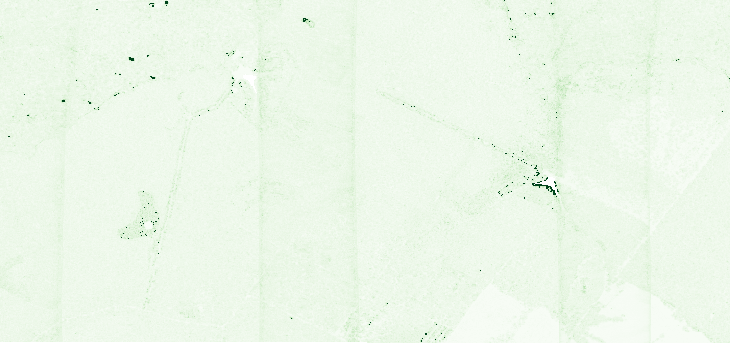

In [7]:
import folium
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
import os

# Input raster (already written by your compute_pai_grid)
input_tif = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW_PAI_10m.tif"
reprojected_tif = input_tif.replace(".tif", "_wgs84.tif")

# Step 1: Reproject to EPSG:4326 (lat/lon)
dst_crs = "EPSG:4326"
with rasterio.open(input_tif) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    with rasterio.open(reprojected_tif, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )

print("✅ Reprojected raster saved at:", reprojected_tif)

# Step 2: Get bounds + min/max values for colormap
with rasterio.open(reprojected_tif) as src:
    bounds = src.bounds
    array = src.read(1, masked=True)
    arr_min, arr_max = float(np.nanmin(array)), float(np.nanmax(array))

print(f"Raster PAI range: {arr_min:.2f} → {arr_max:.2f}")

# Step 3: Make folium map
m = folium.Map(
    location=[(bounds.bottom + bounds.top) / 2, (bounds.left + bounds.right) / 2],
    zoom_start=11,
    tiles="CartoDB positron"
)

# Normalize values to 0–255 for visualization
from matplotlib import cm, colors
cmap = cm.get_cmap("Greens")   # light green → dark green
norm = colors.Normalize(vmin=arr_min, vmax=arr_max)
rgba_img = (cmap(norm(array.filled(np.nan))) * 255).astype(np.uint8)

# Save as temporary PNG for overlay
png_path = reprojected_tif.replace(".tif", ".png")
plt.imsave(png_path, rgba_img)

# Overlay on folium map
folium.raster_layers.ImageOverlay(
    name="PAI",
    image=png_path,
    bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
    opacity=0.7,
).add_to(m)

folium.LayerControl().add_to(m)

m


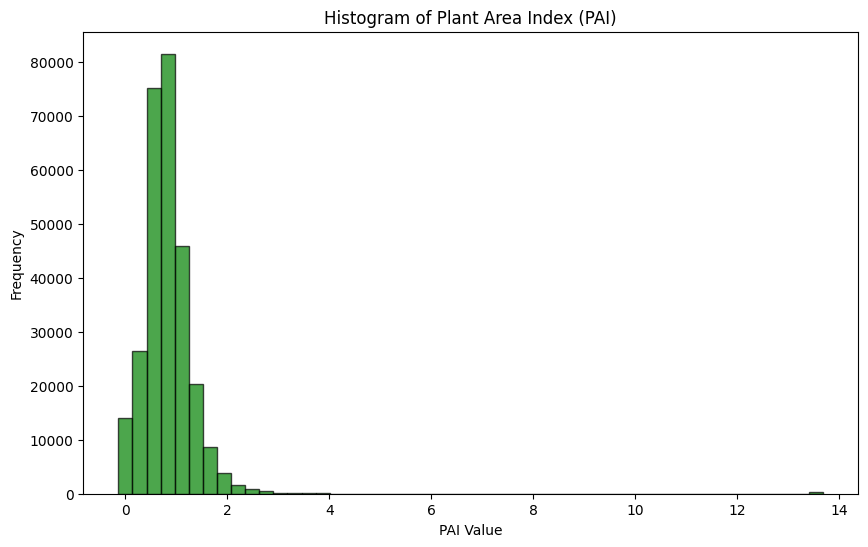

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

raster_path = "/content/drive/MyDrive/GEDI_LAS_Comp/1982317NW_PAI_10m.tif"

# Open raster
with rasterio.open(raster_path) as src:
    array = src.read(1, masked=True).astype(float)  # Read first band

# Mask invalid values
array = np.ma.masked_invalid(array)

# Flatten valid values for histogram
valid_values = array.compressed()  # removes masked/NaN

# Compute histogram
hist, bins = np.histogram(valid_values, bins=50)  # 50 bins, adjust if needed

# Plot histogram
plt.figure(figsize=(10,6))
plt.bar(bins[:-1], hist, width=(bins[1]-bins[0]), color='green', edgecolor='black', alpha=0.7)
plt.xlabel("PAI Value")
plt.ylabel("Frequency")
plt.title("Histogram of Plant Area Index (PAI)")
plt.show()
